<a href="https://colab.research.google.com/github/vvrgit/ML-Optimization/blob/main/Adagrad_Assignmnet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

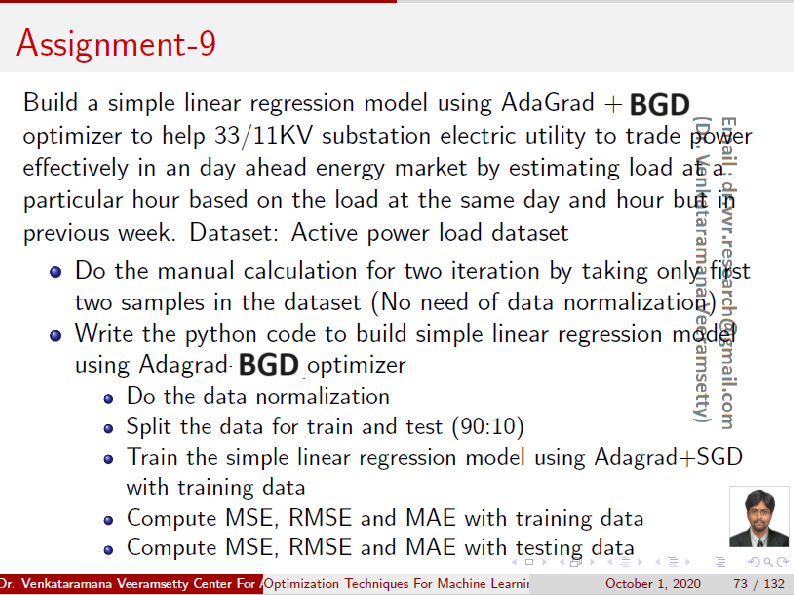

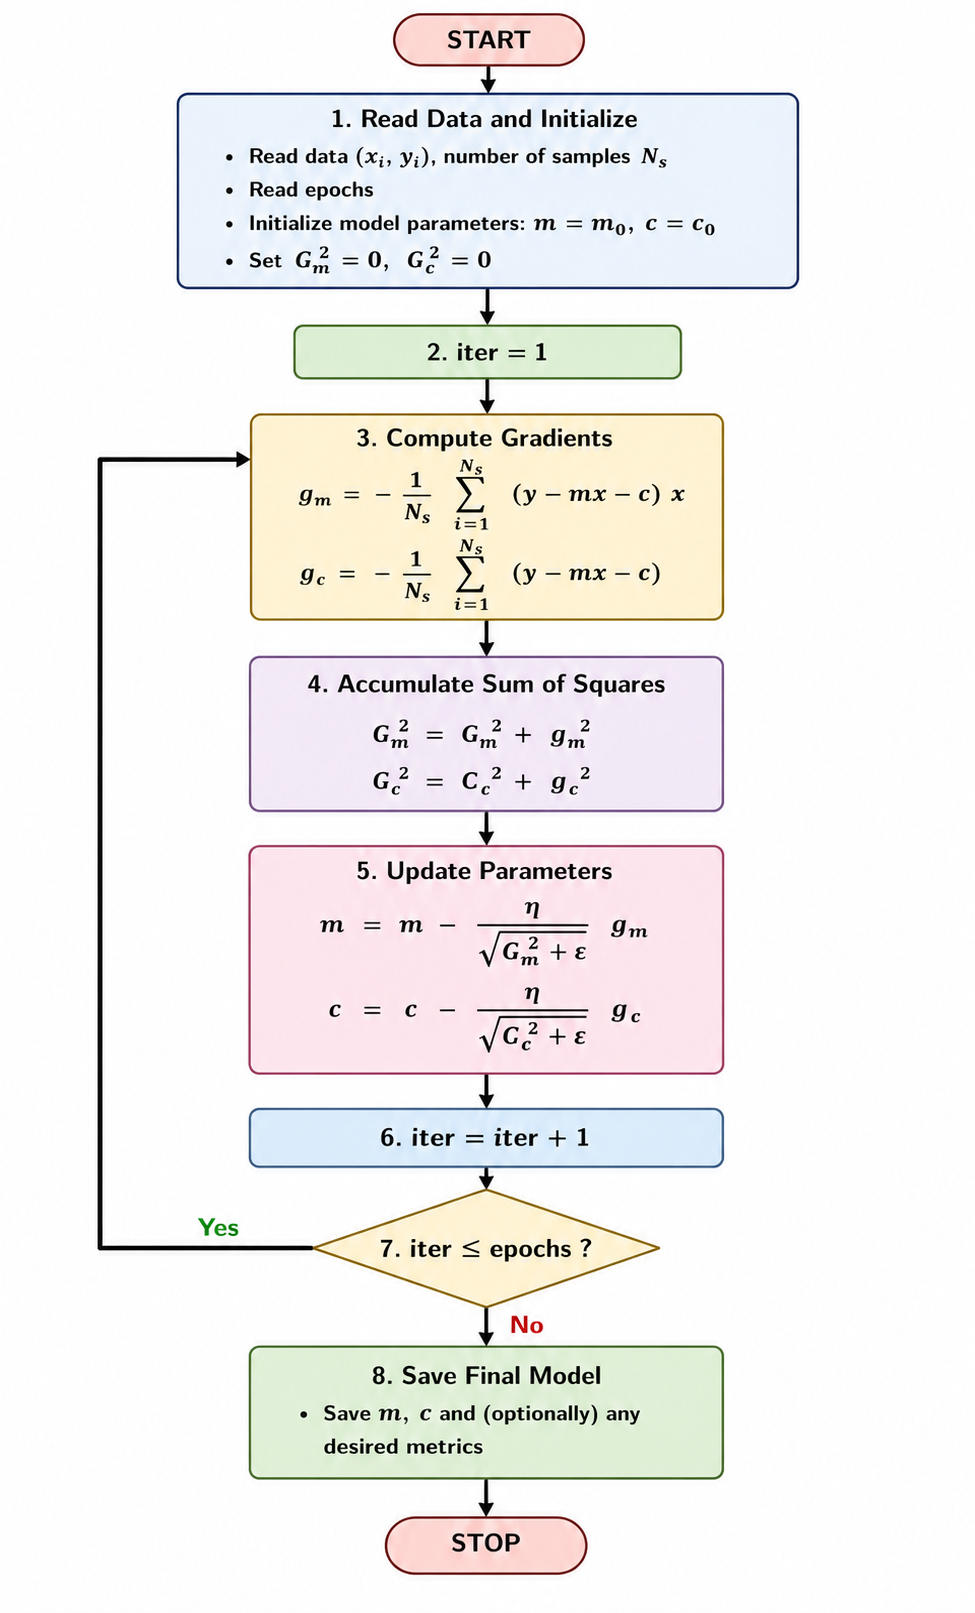

# **Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import random
import math as mt

# **Read Data**

In [2]:
data=pd.read_csv("/content/Dataset-AdaGrad-Assignment.csv")
data.head()

,L(T-168),L(T)
0,5551.82208,5346.52812
1,4983.17184,5138.89596
2,4888.39680,4940.77248
3,5072.95872,4766.18688
4,5196.25980,5020.11540


# **Extract Min and Max values**

In [5]:
x_min=data["L(T-168)"].min()
x_max=data["L(T-168)"].max()
y_min=data["L(T)"].min()
y_max=data["L(T)"].max()

# **Data Normalization**

In [6]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
scaler.fit(data)
data_norm=scaler.transform(data)
data_norm

array([[0.39751641, 0.36030356],
       [0.29337711, 0.32230179],
       [0.27602055, 0.28604034],
       ...,
       [0.62292321, 0.24629825],
       [0.48983728, 0.32438447],
       [0.09691693, 0.65165045]])

# **Make Dataframe**

In [7]:
data=pd.DataFrame(data_norm,columns=["x","y"])
data.head()

,x,y
0,0.397516,0.360304
1,0.293377,0.322302
2,0.276021,0.286040
3,0.309820,0.254087
4,0.332401,0.300562


# **Data Split**

In [9]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(data["x"],data["y"],test_size=0.2,random_state=42)

# **ADAGRAD Optimizer implementation**

In [11]:
Ns=x_train.shape[0]
epochs=500
eta=0.9
m=random.uniform(-1,1)
c=random.uniform(-1,1)
eps=mt.pow(10,-1)
Gm=0
Gc=0

# **Iterative Process**

In [12]:
for iter in range(epochs):
  gm=0
  gc=0
  for sample in range(Ns):
    x=x_train.iloc[sample]
    y=y_train.iloc[sample]
    gm=gm+(y-m*x-c)*x
    gc=gc+(y-m*x-c)
  gm=gm*(-1/Ns)
  gc=gc*(-1/Ns)
  Gm=Gm+(gm*gm)
  Gc=Gc+(gc*gc)
  m=m-eta*(gm/(mt.sqrt(Gm+eps)))
  c=c-eta*(gc/(mt.sqrt(Gc+eps)))
print(m,c)

0.5227323070307697 0.22135164995378473


# **Predictions with training data**

In [15]:
y_pred_train=[]
for i in x_train:
  y_pred_train.append(m*i+c)
y_pred_train=np.array(y_pred_train)
print(y_pred_train)

[0.44593404 0.56082174 0.45918515 ... 0.52212791 0.28553297 0.35147514]


# **Predictions with testing data**

In [16]:
y_pred_test=[]
for i in x_test:
  y_pred_test.append(m*i+c)
y_pred_test=np.array(y_pred_test)
print(y_pred_test)

[0.39237748 0.35801116 0.4994906  0.38736355 0.43607032 0.32833047
 0.46561671 0.42108822 0.43278739 0.35727996 0.39292961 0.54366096
 0.45734969 0.59832178 0.572312   0.67190422 0.38437907 0.42747501
 0.46746709 0.49231292 0.61660174 0.41611905 0.59003983 0.40533014
 0.45248498 0.52470949 0.43442886 0.34620752 0.62310791 0.38464767
 0.45412645 0.34489435 0.43102655 0.60355955 0.54933148 0.67650033
 0.40159954 0.53291682 0.4558873  0.53703541 0.45254467 0.51157776
 0.37993219 0.65674304 0.51384597 0.48429958 0.38836335 0.42950446
 0.35317629 0.66702459 0.50936924 0.50665336 0.43442886 0.56082174
 0.45905085 0.62612224 0.50977215 0.47710697 0.38903486 0.45491734
 0.53948268 0.53127535 0.32773357 0.43595095 0.35472822 0.56353762
 0.48485171 0.42883295 0.45045554 0.72332687 0.39173582 0.61654205
 0.40801618 0.35295246 0.38725909 0.56619381 0.46761632 0.40515107
 0.5772364  0.63124063 0.40027144 0.45690202 0.39342205 0.4994906
 0.26034393 0.46424385 0.34558078 0.39624239 0.519994   0.40324

# **Error computation**

In [18]:
from sklearn.metrics import mean_squared_error
print("Training Error:",mean_squared_error(y_train,y_pred_train))
print("Testing Error:",mean_squared_error(y_test,y_pred_test))


Training Error: 0.028927056626496812
Testing Error: 0.03450342914200322


# **Deployment**

In [19]:
x=input("enter last week load on substation")
x=float(x)
x=(x-x_min)/(x_max-x_min)
yp_norm=m*x+c
yp=yp_norm*(y_max-y_min)+y_min
print("Predicted load on the next week:",yp)

enter last week load on substation5551
Predicted load on the next week: 5722.237782064194
